# Ecommerce Data Engineering Project

### Exploratory Data Analysis & Data Cleaning Pipeline for Olist Brazilian E-Commerce Dataset

Olist is the largest department store operating within marketplaces. It has a catalog of more than 950,000 products, hundreds of thousands of orders, and a network of over 9,000 partner sellers distributed across all regions of Brazil.

In [1]:
import pandas as pd
import numpy as np
import unidecode

In [2]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#### Customer Data

In [3]:
customers = pd.read_csv('raw/olist_customers_dataset.csv')

In [4]:
print("Customers Data Shape = ", customers.shape)

Customers Data Shape =  (99441, 5)


In [5]:
print("Customers Data initial look:")
display(customers.head())
print(customers.info())

Customers Data initial look:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None


In [6]:
print("Count of NULLs in Customer Data:")
print(customers.isna().sum())

Count of NULLs in Customer Data:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [7]:
dupes = customers.duplicated(subset=["customer_id"])
print("Duplicated rows:")
customers[dupes]

Duplicated rows:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


In [8]:
customers['customer_city'].value_counts()

customer_city
sao paulo              15540
rio de janeiro          6882
belo horizonte          2773
brasilia                2131
curitiba                1521
                       ...  
siriji                     1
natividade da serra        1
monte bonito               1
sao rafael                 1
eugenio de castro          1
Name: count, Length: 4119, dtype: int64

In [9]:
customers['customer_city'].unique()

<StringArray>
[               'franca', 'sao bernardo do campo',             'sao paulo',
       'mogi das cruzes',              'campinas',        'jaragua do sul',
               'timoteo',              'curitiba',        'belo horizonte',
         'montes claros',
 ...
              'balbinos',          'serra bonita',          'venda branca',
           'sanga puita',               'queiroz',                'siriji',
   'natividade da serra',          'monte bonito',            'sao rafael',
     'eugenio de castro']
Length: 4119, dtype: str

In [10]:
customers['customer_city'] = (customers['customer_city'].str.strip().str.lower().apply(unidecode.unidecode))          # remove accents (são → sao))

In [11]:
customers['customer_city'].value_counts()

customer_city
sao paulo              15540
rio de janeiro          6882
belo horizonte          2773
brasilia                2131
curitiba                1521
                       ...  
siriji                     1
natividade da serra        1
monte bonito               1
sao rafael                 1
eugenio de castro          1
Name: count, Length: 4119, dtype: int64

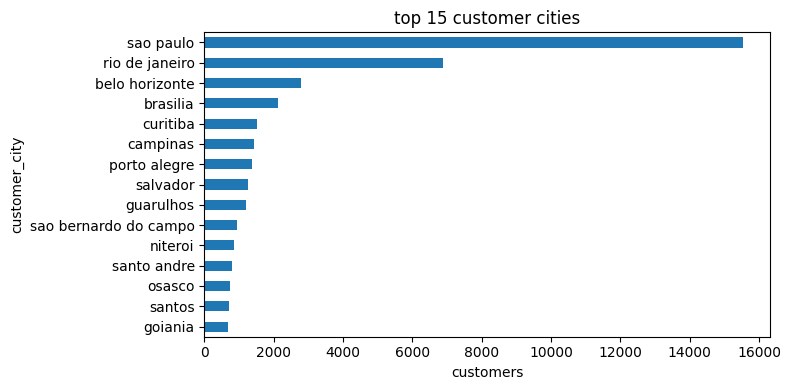

In [12]:
top_cities = customers['customer_city'].value_counts().head(15)
top_cities[::-1].plot(kind='barh', figsize=(8, 4))
plt.title('top 15 customer cities')
plt.xlabel('customers')
plt.tight_layout()
plt.show()

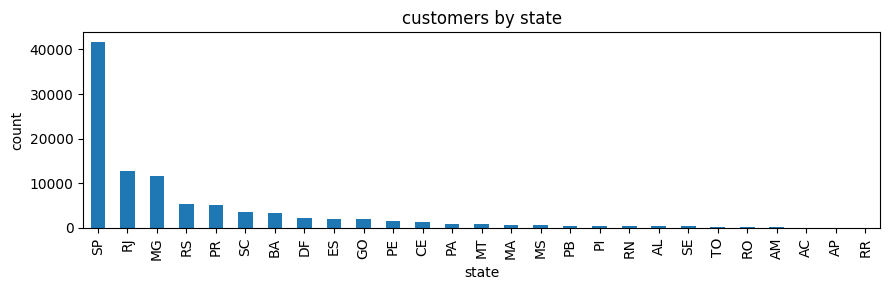

In [13]:
customers['customer_state'].value_counts().plot(kind='bar', figsize=(9, 3))
plt.title('customers by state')
plt.xlabel('state')
plt.ylabel('count')
plt.tight_layout()
plt.show()

SP dominates — not surprising, it's the most populous state in Brazil. The long tail of smaller states is worth keeping in mind when thinking about shipping coverage.

#### Geolocation Data

In [14]:
geolocation = pd.read_csv('raw/olist_geolocation_dataset.csv')

In [15]:
print("Geolocation Data Shape = ", geolocation.shape)

Geolocation Data Shape =  (1000163, 5)


In [16]:
print("Geolocation Data initial look:")
display(geolocation.head())
print(geolocation.info())

Geolocation Data initial look:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB
None


In [17]:
print("Count of NULLs in Geolocation Data:")
print(geolocation.isna().sum())

Count of NULLs in Geolocation Data:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


In [18]:
dupes = geolocation.duplicated()
print("Duplicated rows:")
geolocation[geolocation.duplicated()]

Duplicated rows:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP
...,...,...,...,...,...
1000153,99970,-28.343273,-51.873734,ciriaco,RS
1000154,99950,-28.070493,-52.011342,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS


In [19]:
geolocation['geolocation_city'] = geolocation['geolocation_city'].str.strip().str.lower().apply(unidecode.unidecode)
geolocation['geolocation_state'] = geolocation['geolocation_state'].str.strip().str.upper().apply(unidecode.unidecode)

In [20]:
geolocation = geolocation.drop_duplicates(subset='geolocation_lat',keep='first')

In [21]:
dupes = geolocation.duplicated()
print("Duplicated rows:")
geolocation[geolocation.duplicated()]

Duplicated rows:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state


In [22]:
print("Resetting index after dropping duplicates...")
geolocation = geolocation.reset_index(drop=True)

Resetting index after dropping duplicates...


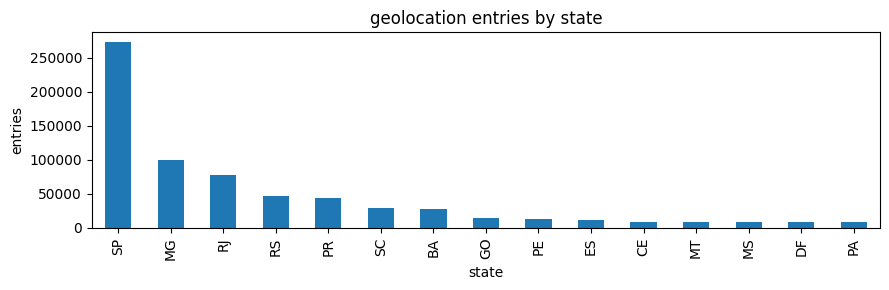

In [23]:
geolocation['geolocation_state'].value_counts().head(15).plot(kind='bar', figsize=(9, 3))
plt.title('geolocation entries by state')
plt.xlabel('state')
plt.ylabel('entries')
plt.tight_layout()
plt.show()

Sao Paulo seems to be the most common.

#### Order_item Data

In [24]:
order_item = pd.read_csv('raw/olist_order_items_dataset.csv')

In [25]:
print("Order_item Data Shape = ", order_item.shape)

Order_item Data Shape =  (112650, 7)


In [26]:
print("Order_item Data initial look:")
display(order_item.head())
print(order_item.info())

Order_item Data initial look:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB
None


In [27]:
order_item['shipping_limit_date'] = pd.to_datetime(order_item['shipping_limit_date'])
print("Converted shipping_limit_date column to the correct datatype.")

Converted shipping_limit_date column to the correct datatype.


In [28]:
order_item.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB


In [29]:
order_item['order_id'] = order_item['order_id'].str.strip()
order_item['product_id'] = order_item['product_id'].str.strip()
order_item['seller_id'] = order_item['seller_id'].str.strip()
print("Cleaned str columns.")

Cleaned str columns.


In [30]:
dupes = order_item.duplicated(subset=["order_id", "order_item_id"])
print("Duplicated rows:")
order_item[dupes]

Duplicated rows:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


Price and freight are the two numeric columns worth looking at. Let's see their distributions before anything gets transformed.

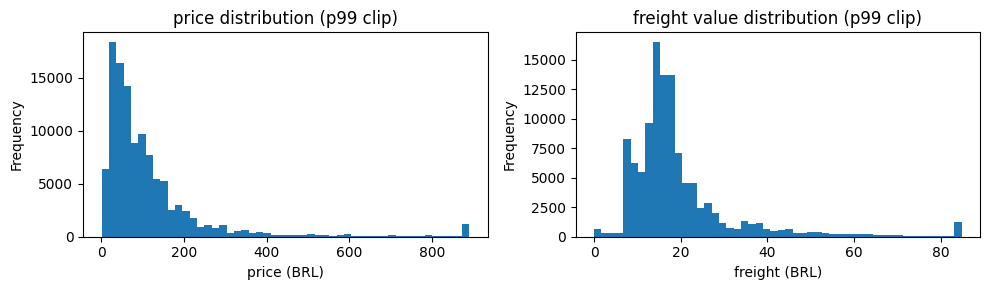

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
order_item['price'].clip(upper=order_item['price'].quantile(0.99)).plot(kind='hist', bins=50, ax=axes[0])
axes[0].set_title('price distribution (p99 clip)')
axes[0].set_xlabel('price (BRL)')

order_item['freight_value'].clip(upper=order_item['freight_value'].quantile(0.99)).plot(kind='hist', bins=50, ax=axes[1])
axes[1].set_title('freight value distribution (p99 clip)')
axes[1].set_xlabel('freight (BRL)')

plt.tight_layout()
plt.show()

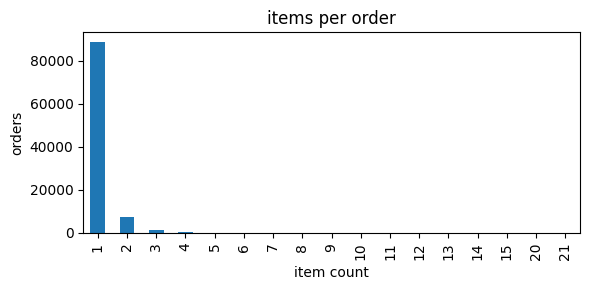

In [32]:
order_item.groupby('order_id')['order_item_id'].max().value_counts().sort_index().plot(kind='bar', figsize=(6, 3))
plt.title('items per order')
plt.xlabel('item count')
plt.ylabel('orders')
plt.tight_layout()
plt.show()

Most orders are single-item — the classic marketplace pattern. Multi-item orders drop off sharply. Price is right-skewed with a heavy tail (a few expensive products), while freight clusters tightly in the 10–30 BRL range.

#### Order Reviews Data

In [33]:
order_reviews = pd.read_csv('raw/olist_order_reviews_dataset.csv')

In [34]:
print("Order Reviews Data Shape = ", order_reviews.shape)

Order Reviews Data Shape =  (99224, 7)


In [35]:
print("Order Review Data initial look:")
display(order_reviews.head())
print(order_reviews.info())

Order Review Data initial look:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB
None


In [36]:
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])
print("Converted review_creation_date and review_answer_timestamp to the correct datatype.")

Converted review_creation_date and review_answer_timestamp to the correct datatype.


In [37]:
order_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  str           
 1   order_id                 99224 non-null  str           
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  str           
 4   review_comment_message   40977 non-null  str           
 5   review_creation_date     99224 non-null  datetime64[us]
 6   review_answer_timestamp  99224 non-null  datetime64[us]
dtypes: datetime64[us](2), int64(1), str(4)
memory usage: 5.3 MB


In [38]:
print("Count of NULLs in Order Reviews Data:")
print(order_reviews.isna().sum())

Count of NULLs in Order Reviews Data:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


In [39]:
order_reviews['review_comment_title'] = order_reviews['review_comment_title'].fillna('No Review Title')
order_reviews['review_comment_message'] = order_reviews['review_comment_message'].fillna('No Review Message')
print("Filled nulls in titles and comments.")

Filled nulls in titles and comments.


In [40]:
order_reviews['review_id'] = order_reviews['review_id'].str.strip()
print("Cleaned str columns.")

Cleaned str columns.


In [41]:
print("Count of NULLs in Order Reviews Data:")
print(order_reviews.isna().sum())

Count of NULLs in Order Reviews Data:
review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64


In [42]:
dupes = order_reviews.duplicated(subset=["review_id"])
print("Duplicated rows:")
order_reviews[dupes]

Duplicated rows:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
3317,3242cc306a9218d0377831e175d62fbf,9c5bfba7de6a4abbb6ba0baab78d1622,5,No Review Title,Ótimo,2017-07-21,2017-07-22 01:06:37
5719,308316408775d1600dad81bd3184556d,3fe4dbcdb046a475dbf25463c1ca78bd,5,No Review Title,Ajudem a rastrear uma das 3 prateleiras que fa...,2017-09-07,2017-09-11 09:58:09
7213,8ee90ac383cf825bb7f4756130d4e74a,75d5d3d16567a27eefc5752aeb063072,5,No Review Title,recomendo,2017-05-30,2017-06-02 18:16:17
7805,d433c252647c51309432ca0b763f969b,191abde9c3bf77d1ce67d100d8db6d15,1,No Review Title,No Review Message,2017-09-03,2017-09-06 16:11:00
9013,03a6a25db577d0689440933055111897,3fde8b7313af6b37b84b5c7594d7add0,5,No Review Title,Muito Bom! Gostei Bastante! Tecido Ótimo! Aten...,2017-12-15,2017-12-16 01:32:18
...,...,...,...,...,...,...,...
99108,2c6c08892b83ba4c1be33037c2842294,42ae1967f68c90bb325783ac55d761ce,4,No Review Title,"Chegou um pouco amassada, mas nada de mais, e ...",2017-07-03,2017-07-05 19:06:59
99124,6ec93e77f444e0b1703740a69122e35d,e1fdc6e9d1ca132377e862593a7c0bd4,5,No Review Title,Vendedor compromisso do vou o cliente,2017-10-07,2017-10-07 19:47:11
99164,2afe63a67dfd99b3038f568fb47ee761,c5334d330e36d2a810a7a13c72e135ee,5,No Review Title,"Muito bom, produto conforme anunciado, entrega...",2018-03-03,2018-03-04 22:56:47
99167,017808d29fd1f942d97e50184dfb4c13,b1461c8882153b5fe68307c46a506e39,5,No Review Title,No Review Message,2018-03-02,2018-03-05 01:43:30


In [43]:
order_reviews = order_reviews.drop_duplicates(subset='review_id', keep='first')

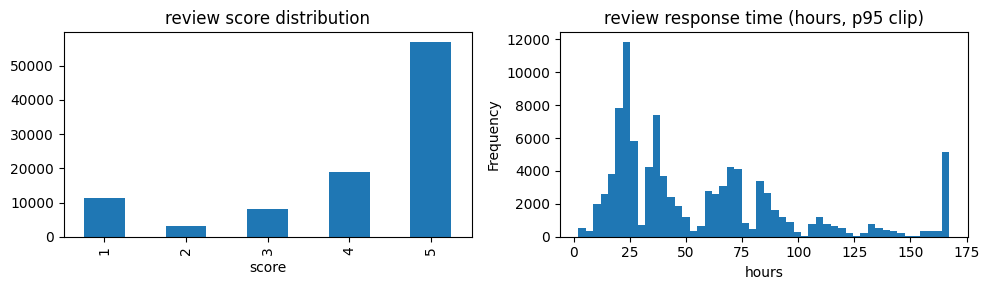

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

order_reviews['review_score'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('review score distribution')
axes[0].set_xlabel('score')

resp_hours = (order_reviews['review_answer_timestamp'] - order_reviews['review_creation_date']).dt.total_seconds() / 3600
resp_hours.clip(lower=0, upper=resp_hours.quantile(0.95)).plot(kind='hist', bins=50, ax=axes[1])
axes[1].set_title('review response time (hours, p95 clip)')
axes[1].set_xlabel('hours')

plt.tight_layout()
plt.show()

5-star reviews dominate — roughly half of all reviews. The 1-star bucket is the second largest, which is the typical bimodal pattern for e-commerce ratings (happy customers bother, unhappy customers really bother). Response times cluster in the first 48 hours with a long tail.

#### Order Data

In [45]:
orders = pd.read_csv('raw/olist_orders_dataset.csv')

In [46]:
print("Orders Data Shape = ", orders.shape)

Orders Data Shape =  (99441, 4)


In [47]:
print("Orders Data initial look:")
display(orders.head())
print(orders.info())

Orders Data initial look:


,order_id,customer_id,order_status,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,7/24/2018 20:41
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,8/8/2018 8:38
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,11/18/2017 19:28
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2/13/2018 21:18


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   order_id                  99441 non-null  str  
 1   customer_id               99441 non-null  str  
 2   order_status              99441 non-null  str  
 3   order_purchase_timestamp  99441 non-null  str  
dtypes: str(4)
memory usage: 3.0 MB
None


In [48]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
print("Converted order_purchase_timestamp to the correct datatype.")

Converted order_purchase_timestamp to the correct datatype.


In [49]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  99441 non-null  str           
 1   customer_id               99441 non-null  str           
 2   order_status              99441 non-null  str           
 3   order_purchase_timestamp  99441 non-null  datetime64[us]
dtypes: datetime64[us](1), str(3)
memory usage: 3.0 MB


In [50]:
print("Count of NULLs in Orders Data:")
print(orders.isna().sum())

Count of NULLs in Orders Data:
order_id                    0
customer_id                 0
order_status                0
order_purchase_timestamp    0
dtype: int64


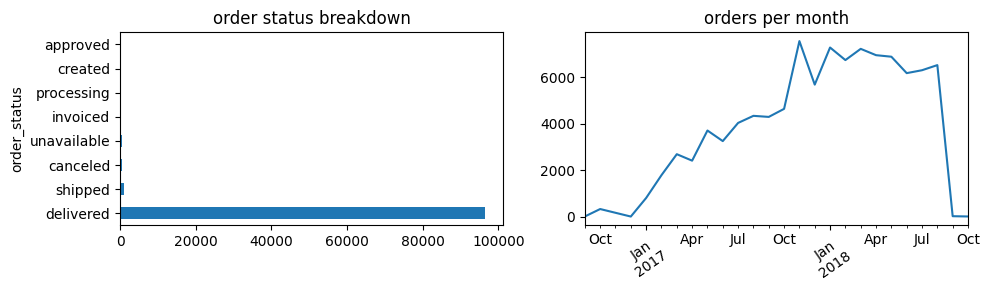

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

orders['order_status'].value_counts().plot(kind='barh', ax=axes[0])
axes[0].set_title('order status breakdown')

orders['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index().plot(kind='line', ax=axes[1])
axes[1].set_title('orders per month')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

The overwhelming majority of orders ended up delivered — good signal for data completeness. The time series shows clear growth through 2017 into early 2018, then a sudden drop at the end which is likely a data cutoff artifact, not a real business event.

#### Products Data

In [52]:
products = pd.read_csv('raw/olist_products_dataset.csv')

In [53]:
print("Products Data Shape = ", products.shape)

Products Data Shape =  (32951, 9)


In [54]:
print("Products Data initial look:")
display(products.head())
print(products.info())

Products Data initial look:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB
None


In [55]:
print("Count of NULLs in Order Reviews Data:")
print(products.isna().sum())

Count of NULLs in Order Reviews Data:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [56]:
products[products['product_category_name'].isnull()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [57]:
products['product_weight_g'] = products['product_weight_g'].fillna(0)
products['product_length_cm'] = products['product_length_cm'].fillna(0)
products['product_height_cm'] = products['product_height_cm'].fillna(0)
products['product_width_cm'] = products['product_width_cm'].fillna(0)


In [58]:
products['product_category_name']=products['product_category_name'].fillna('unknown')
products['product_name_lenght']=products['product_name_lenght'].fillna(0)
products['product_description_lenght']=products['product_description_lenght'].fillna(0)
products['product_photos_qty']=products['product_photos_qty'].fillna(0)

In [59]:
products[products['product_category_name'].isnull()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


In [60]:
products[products.duplicated()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


In [61]:
products['product_id'] = products['product_id'].str.strip()

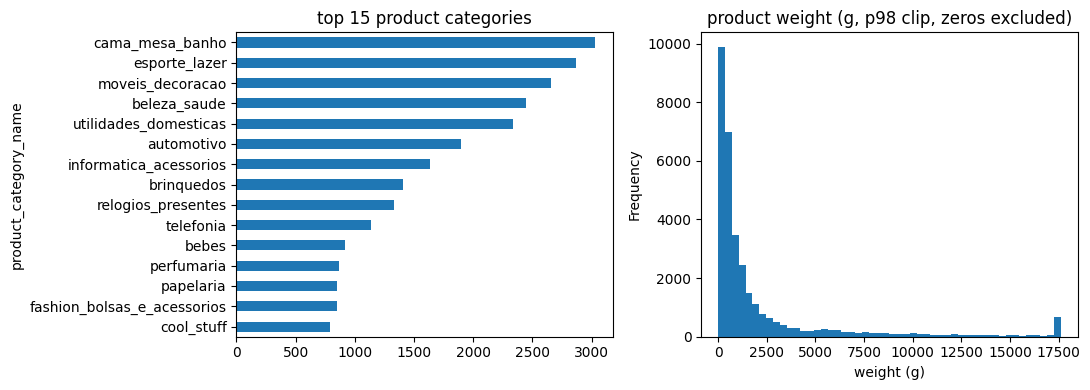

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

products['product_category_name'].value_counts().head(15)[::-1].plot(kind='barh', ax=axes[0])
axes[0].set_title('top 15 product categories')

products['product_weight_g'][products['product_weight_g'] > 0].clip(upper=products['product_weight_g'].quantile(0.98)).plot(kind='hist', bins=50, ax=axes[1])
axes[1].set_title('product weight (g, p98 clip, zeros excluded)')
axes[1].set_xlabel('weight (g)')

plt.tight_layout()
plt.show()

Category distribution is uneven — a handful of categories account for most of the catalog. Weight is expectably skewed: most products are under 2kg (think electronics, books, accessories), with a long tail of heavy items that will likely carry higher freight costs.

#### Sellers Data

In [63]:
sellers = pd.read_csv('raw/olist_sellers_dataset.csv')

In [64]:
print("Customers Data Shape = ", sellers.shape)

Customers Data Shape =  (3095, 4)


In [65]:
print("Sellers Data initial look:")
display(sellers.head())
print(sellers.info())

Sellers Data initial look:


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB
None


In [66]:
print("Count of NULLs in Sellers Data:")
print(sellers.isna().sum())

Count of NULLs in Sellers Data:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


In [67]:
sellers[sellers.duplicated()]

,seller_id,seller_zip_code_prefix,seller_city,seller_state


In [68]:
sellers['seller_id'] = sellers['seller_id'].str.strip()

In [69]:
sellers['seller_city'].value_counts()

seller_city
sao paulo                 694
curitiba                  127
rio de janeiro             96
belo horizonte             68
ribeirao preto             52
                         ... 
aparecida de goiania        1
bandeirantes                1
vitoria de santo antao      1
palotina                    1
leme                        1
Name: count, Length: 611, dtype: int64

In [70]:
sellers['seller_city'] = sellers['seller_city'].str.strip().str.lower()

In [71]:
sellers['seller_city'].value_counts()

seller_city
sao paulo                 694
curitiba                  127
rio de janeiro             96
belo horizonte             68
ribeirao preto             52
                         ... 
aparecida de goiania        1
bandeirantes                1
vitoria de santo antao      1
palotina                    1
leme                        1
Name: count, Length: 611, dtype: int64

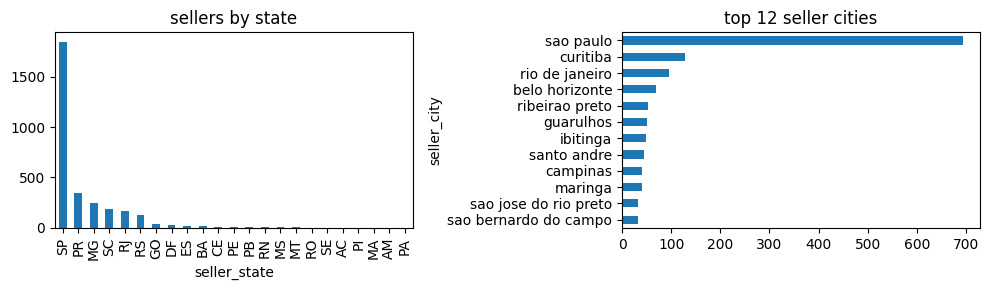

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

sellers['seller_state'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('sellers by state')

sellers['seller_city'].value_counts().head(12)[::-1].plot(kind='barh', ax=axes[1])
axes[1].set_title('top 12 seller cities')

plt.tight_layout()
plt.show()

Sellers are heavily concentrated in SP — same pattern as customers, but even more pronounced. The seller base being in the south-east while customers are distributed nationally is part of what makes Olist's logistics interesting.

#### Product Translation Lookup Table

In [73]:
products_translation = pd.read_csv('raw/product_category_name_translation.csv')

In [74]:
products_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [75]:
products_translation.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


In [76]:
products.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

##### Merging English product names into products DF

In [77]:
products = pd.merge(products, products_translation, on="product_category_name", how="left")
products.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [78]:
cols = list(products.columns)
cols.insert(2, cols.pop(cols.index('product_category_name_english')))
products = products[cols]
products.head(5)

,product_id,product_category_name,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0


#### Merging geolocation data into customers and sellers DFs

In [79]:
geo_agg = geolocation.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean'),
    city=('geolocation_city', lambda x: x.mode()[0]),  # most frequent city name
    state=('geolocation_state', lambda x: x.mode()[0])
).reset_index()

In [80]:
customers_geo = pd.merge(
    customers[['customer_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']],
    geo_agg[['geolocation_zip_code_prefix', 'lat', 'lng']],  # only take lat/lng from geo
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).drop(columns='geolocation_zip_code_prefix').rename(columns={
    'customer_zip_code_prefix': 'zip_code_prefix',
    'customer_city': 'city',
    'customer_state': 'state'
})

In [81]:
sellers_geo = pd.merge(
    sellers[['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']],
    geo_agg[['geolocation_zip_code_prefix', 'lat', 'lng']],
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).drop(columns='geolocation_zip_code_prefix').rename(columns={
    'seller_zip_code_prefix': 'zip_code_prefix',
    'seller_city': 'city',
    'seller_state': 'state'
})

In [82]:
customers = customers_geo
sellers = sellers_geo

In [83]:
customers.to_csv('output/customers_cleaned.csv',index=False, encoding='utf-8-sig')
order_item.to_csv('output/order_item_cleaned.csv',index=False, encoding='utf-8-sig')
order_reviews.to_csv('output/order_reviews_cleaned.csv',index=False, encoding='utf-8-sig')
orders.to_csv('output/orders_cleaned.csv',index=False, encoding='utf-8-sig')
products.to_csv('output/products_cleaned.csv',index=False, encoding='utf-8-sig')
sellers.to_csv('output/sellers_cleaned.csv',index=False, encoding='utf-8-sig')

---
### Loading data into MSSQL Server

In [102]:
import pyodbc
import time

In [103]:
SERVER   = r".\KYSERVER"
DATABASE = "Ecommerce_OLTP"

# SQL Server will use your current Windows login automatically.
print(f"Server  : {SERVER}")
print(f"Database: {DATABASE}")
print("Auth    : Windows Authentication (no password)")

Server  : .\KYSERVER
Database: Ecommerce_OLTP
Auth    : Windows Authentication (no password)


#### Connect

In [104]:
conn_str = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"Trusted_Connection=yes;"   # <-- Windows Auth, no password needed
)

conn = pyodbc.connect(conn_str)
print(f"Connected to [{DATABASE}] on [{SERVER}] using Windows Authentication!")

Connected to [Ecommerce_OLTP] on [.\KYSERVER] using Windows Authentication!


#### Create Tables

In [105]:
CREATE_STATEMENTS = {

    "customers": """
        IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='customers' AND xtype='U')
        CREATE TABLE customers (
            customer_id              VARCHAR(50)  NOT NULL,
            zip_code_prefix INT          NOT NULL,
            lat             DECIMAL(18,10)   NULL,
            lng             DECIMAL(18,10)   NULL,
            city            NVARCHAR(100) NOT NULL,
            state           NVARCHAR(10)      NOT NULL,
            CONSTRAINT PK_customers PRIMARY KEY (customer_id)
        );
    """,

    "sellers": """
        IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='sellers' AND xtype='U')
        CREATE TABLE sellers (
            seller_id               VARCHAR(50)  NOT NULL,
            zip_code_prefix  INT            NOT NULL,
            lat              DECIMAL(18,10)     NULL,
            lng              DECIMAL(18,10)     NULL,
            city             NVARCHAR(100)  NOT NULL,
            state            NVARCHAR(10)        NOT NULL,
            CONSTRAINT PK_sellers PRIMARY KEY (seller_id)
        );
    """,

    "products": """
        IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='products' AND xtype='U')
        CREATE TABLE products (
            product_id                          VARCHAR(50)  NOT NULL,
            product_category_name               NVARCHAR(100) NULL,
            product_category_name_english       NVARCHAR(100) NULL,
            product_name_lenght                 FLOAT        NULL,
            product_description_lenght          FLOAT        NULL,
            product_photos_qty                  FLOAT        NULL,
            product_weight_g                    FLOAT        NULL,
            product_length_cm                   FLOAT        NULL,
            product_height_cm                   FLOAT        NULL,
            product_width_cm                    FLOAT        NULL,
            CONSTRAINT PK_products PRIMARY KEY (product_id)
        );
    """,

    "orders": """
        IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='orders' AND xtype='U')
        CREATE TABLE orders (
            order_id                      VARCHAR(50)   NOT NULL,
            customer_id                   VARCHAR(50)   NOT NULL,
            order_status                  NVARCHAR(30)  NOT NULL,
            order_purchase_timestamp      DATETIME2     NULL,
            CONSTRAINT PK_orders PRIMARY KEY (order_id),
            CONSTRAINT FK_orders_customers FOREIGN KEY (customer_id)
                REFERENCES customers(customer_id)
        );
    """,

    "order_items": """
        IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='order_items' AND xtype='U')
        CREATE TABLE order_items (
            order_id            VARCHAR(50)    NOT NULL,
            order_item_id       INT            NOT NULL,
            product_id          VARCHAR(50)    NOT NULL,
            seller_id           VARCHAR(50)    NOT NULL,
            shipping_limit_date DATETIME2      NOT NULL,
            price               DECIMAL(10,2)  NOT NULL,
            freight_value       DECIMAL(10,2)  NOT NULL,
            CONSTRAINT PK_order_items PRIMARY KEY (order_id, order_item_id),
            CONSTRAINT FK_oi_orders   FOREIGN KEY (order_id)   REFERENCES orders(order_id),
            CONSTRAINT FK_oi_products FOREIGN KEY (product_id) REFERENCES products(product_id),
            CONSTRAINT FK_oi_sellers  FOREIGN KEY (seller_id)  REFERENCES sellers(seller_id)
        );
    """,

    "order_reviews": """
        IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='order_reviews' AND xtype='U')
        CREATE TABLE order_reviews (
            review_id               VARCHAR(50)     NOT NULL,
            order_id                VARCHAR(50)     NOT NULL,
            review_score            TINYINT         NOT NULL,
            review_comment_title    NVARCHAR(255)   NULL,
            review_comment_message  NVARCHAR(MAX)   NULL,
            review_creation_date    DATETIME2       NOT NULL,
            review_answer_timestamp DATETIME2       NOT NULL,
            CONSTRAINT PK_order_reviews PRIMARY KEY (review_id),
            CONSTRAINT FK_or_orders FOREIGN KEY (order_id) REFERENCES orders(order_id)
        );
    """,
}

cursor = conn.cursor()
for table_name, sql in CREATE_STATEMENTS.items():
    try:
        cursor.execute(sql)
        conn.commit()
        print(f"Table [{table_name}] is ready.")
    except Exception as e:
        print(f"[{table_name}] failed: {e}")
cursor.close()

Table [customers] is ready.
Table [sellers] is ready.
Table [products] is ready.
Table [orders] is ready.
Table [order_items] is ready.
Table [order_reviews] is ready.


#### Load Cleaned Data into SQL Server

In [723]:
def load_dataframe(conn, df, table_name):
    """Bulk-insert a cleaned DataFrame into a SQL Server table."""

    # Replace NaN / NaT with None so pyodbc sends SQL NULL
    df = df.where(pd.notnull(df), None)
    df = df.replace({float('nan'): None})  # catch any numpy.nan that slipped through

    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):  # remove the `or dtype == object` part
            df[col] = df[col].apply(
                lambda x: float(x) if x is not None else None
            )

    # Convert pandas Timestamps to plain Python datetime (pyodbc needs this)
    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].apply(
                lambda x: x.to_pydatetime() if pd.notnull(x) else None
            )

    columns      = ", ".join(df.columns.tolist())
    placeholders = ", ".join(["?"] * len(df.columns))
    insert_sql   = f"INSERT INTO {table_name} ({columns}) VALUES ({placeholders})"

    BATCH_SIZE = 5000
    data  = df.values.tolist()
    total = len(data)

    cursor = conn.cursor()
    cursor.fast_executemany = True   # big speed boost for large tables

    start = time.time()
    for i in range(0, total, BATCH_SIZE):
        batch = data[i : i + BATCH_SIZE]
        cursor.executemany(insert_sql, batch)
        conn.commit()
        loaded = min(i + BATCH_SIZE, total)
        print(f"  -> {loaded:,} / {total:,} rows ({loaded/total*100:.0f}%)", end="\r")

    elapsed = time.time() - start
    print(f"  -> {total:,} rows loaded in {elapsed:.1f}s          ")
    cursor.close()

print("load_dataframe() function ready.")

load_dataframe() function ready.


In [724]:
float_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
]

for col in float_cols:
    products[col] = pd.to_numeric(products[col], errors='coerce').round(2)
    # Convert to Python float or None — avoids object dtype confusion with fast_executemany
    products[col] = products[col].apply(lambda x: float(x) if pd.notna(x) else None)


print("products dtypes after fix:")
print(products[float_cols].dtypes)
print()
print("Sample values:")
print(products[float_cols].head(3))
print()
print("Any NaN remaining?")
print(products[float_cols].isna().sum())

products dtypes after fix:
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

Sample values:
   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0              14.0  
1            1000.0               30.0               18.0              20.0  
2             154.0               18.0                9.0              15.0  

Any NaN remaining?
product_name_lenght           0
product_descript

In [ ]:
# Load order matters: parent tables must come before child tables (Foreign Keys)
LOAD_ORDER = [
    ("customers",            customers),
    ("sellers",              sellers),
    ("products",             products),
    ("orders",               orders),
    ("order_items",          order_item),
    ("order_reviews",        order_reviews),
]

for table_name, df in LOAD_ORDER:
    print(f"\nLoading [{table_name}]  ({len(df):,} rows)")
    try:
        load_dataframe(conn, df, table_name)
        print(f"  OK [{table_name}] done!")
    except Exception as e:
        print(f"  FAILED [{table_name}]: {e}")


Loading [customers]  (99,441 rows)


  -> 99,441 rows loaded in 4.4s          
  OK [customers] done!

Loading [sellers]  (3,095 rows)
  -> 3,095 rows loaded in 0.1s          
  OK [sellers] done!

Loading [products]  (32,951 rows)
  -> 32,951 rows loaded in 1.4s          
  OK [products] done!

Loading [orders]  (99,441 rows)
  -> 99,441 rows loaded in 8.9s          
  OK [orders] done!

Loading [order_items]  (112,650 rows)
  -> 112,650 rows loaded in 8.8s          
  OK [order_items] done!

Loading [order_reviews]  (98,410 rows)
  -> 98,410 rows loaded in 8.4s          
  OK [order_reviews] done!


In [729]:
conn.close()
print('Connection closed.')
print('All done! Open SSMS and run: SELECT * FROM customers;')

Connection closed.
All done! Open SSMS and run: SELECT * FROM customers;
